In [ ]:
"""
Objective:
Analyze restaurant trends, customer preferences,
pricing patterns, ratings, and factors affecting popularity.
"""

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [96]:
df = pd.read_csv("Zomato-data-.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [8]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [82]:
df.duplicated().sum()

0

In [88]:
duplicates = df[df.duplicated()]
duplicates.head()
df.drop_duplicates(inplace=True)

In [98]:
# Shape of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.info())

df.describe()
df.describe(include='object')

Rows: 148
Columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB
None


,name,online_order,book_table,rate,listed_in(type)
count,148,148,148,148,148
unique,145,2,2,20,4
top,San Churro Cafe,No,No,3.8/5,Dining
freq,2,90,140,19,110


In [78]:
print(df.columns)
print(df.dtypes)
print(df.nunique())

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)', 'Cost_Per_Rating',
       'Popularity_Score', 'Premium_Restaurant'],
      dtype='object')
name                            object
online_order                    object
book_table                      object
rate                           float64
votes                            int64
approx_cost(for two people)      int64
listed_in(type)                 object
Cost_Per_Rating                float64
Popularity_Score               float64
Premium_Restaurant               int64
dtype: object
name                           145
online_order                     2
book_table                       2
rate                            19
votes                           90
approx_cost(for two people)     18
listed_in(type)                  4
Cost_Per_Rating                 91
Popularity_Score               107
Premium_Restaurant               2
dtype: int64


In [20]:
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

In [90]:
df['rate'] = (
    df['rate']
    .astype(str)
    .str.replace('/5','',regex=False)
    .str.strip()
)

df['rate'] = pd.to_numeric(
    df['rate'],
    errors='coerce'
)

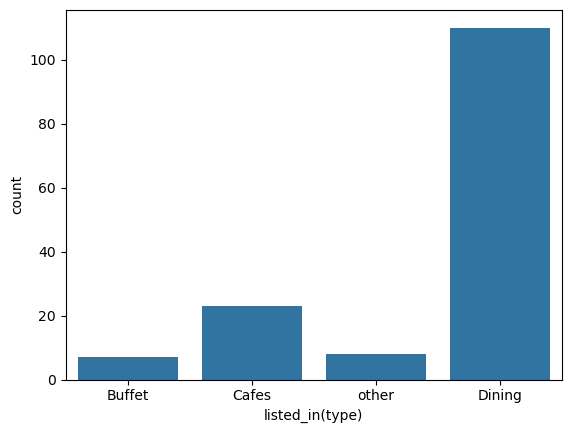

In [22]:
sns.countplot(
    data=df,
    x='listed_in(type)'
)
plt.show()

In [24]:
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

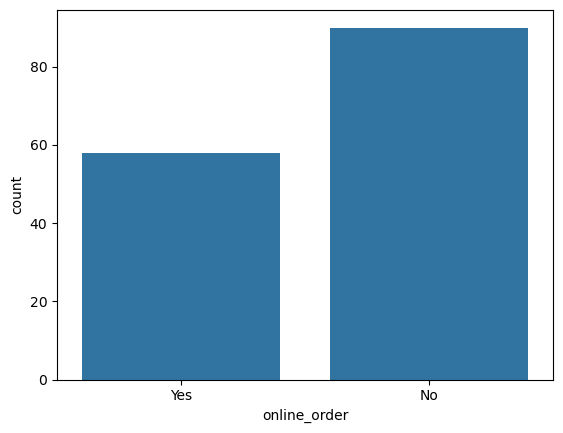

In [26]:
sns.countplot(
    data=df,
    x='online_order'
)
plt.show()

In [28]:
df['book_table'].value_counts()

book_table
No     140
Yes      8
Name: count, dtype: int64

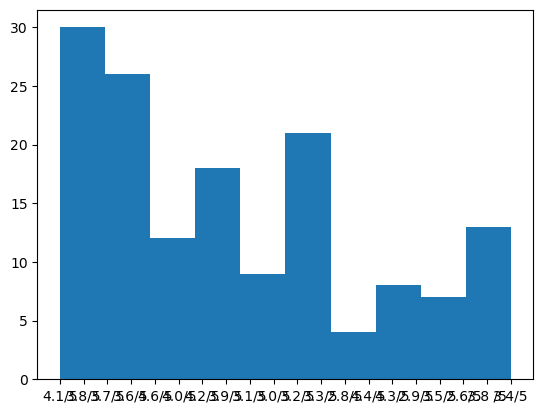

In [30]:
plt.hist(df['rate'], bins=10)
plt.show()

In [94]:
df['rate'].mean()

3.6331081081081082

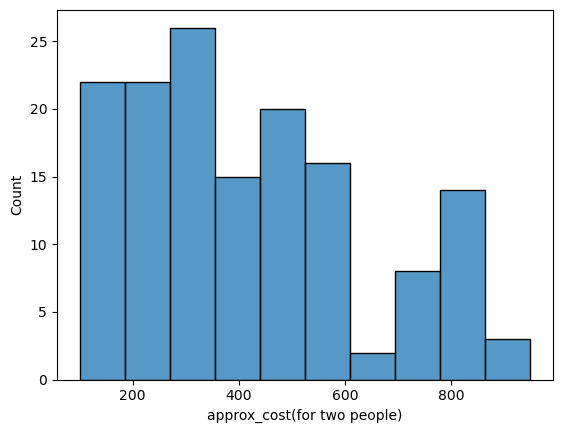

In [34]:
sns.histplot(
    df['approx_cost(for two people)'],
    bins=10
)
plt.show()

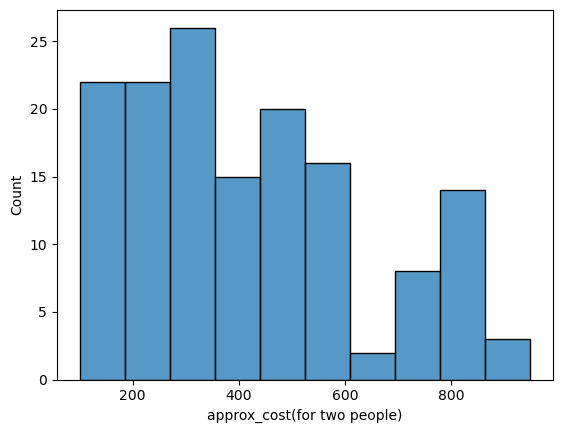

In [42]:
sns.histplot(
    df['approx_cost(for two people)'],
    bins=10
)
plt.show()

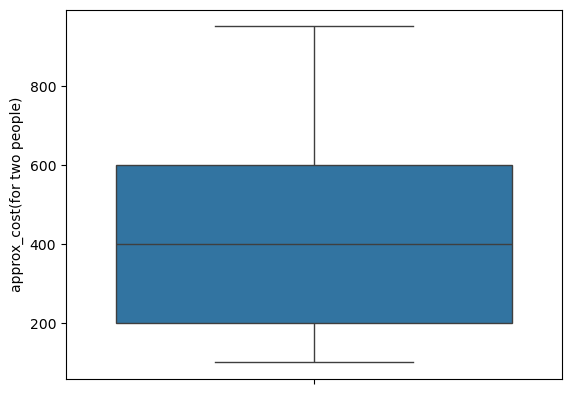

In [44]:
sns.boxplot(
    y=df['approx_cost(for two people)']
)
plt.show()

In [50]:
df.groupby(
    'listed_in(type)'
)['rate'].mean()


listed_in(type)
Buffet    3.842857
Cafes     3.765217
Dining    3.571818
other     3.912500
Name: rate, dtype: float64

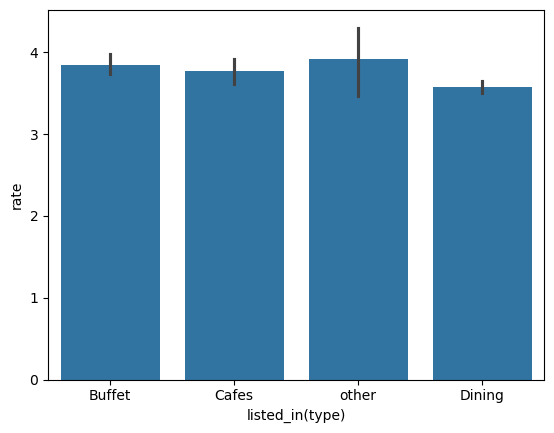

In [52]:
sns.barplot(
    data=df,
    x='listed_in(type)',
    y='rate'
)
plt.show()

In [54]:
df.groupby(
    'online_order'
)['rate'].mean()

online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64

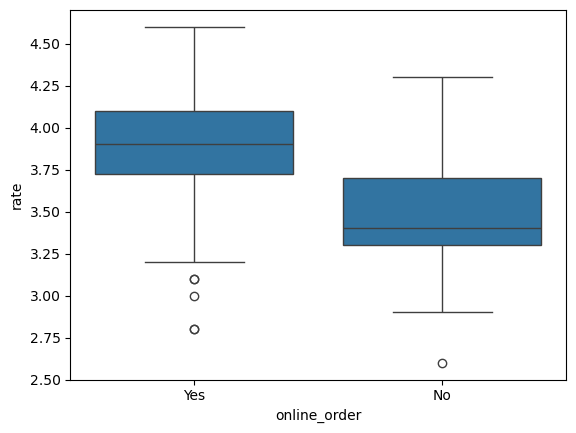

In [56]:
sns.boxplot(
    data=df,
    x='online_order',
    y='rate'
)
plt.show()

In [58]:
df.groupby(
    'book_table'
)['rate'].mean()

book_table
No     3.601429
Yes    4.187500
Name: rate, dtype: float64

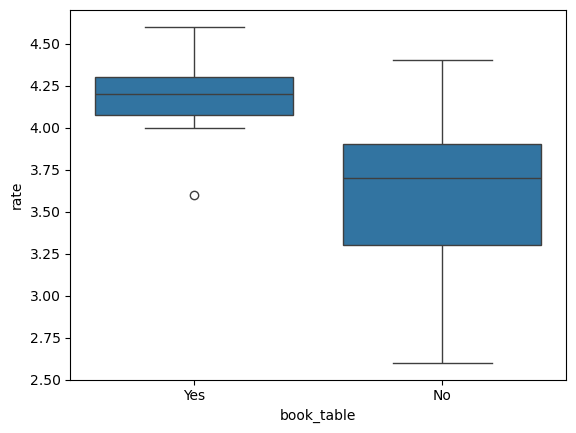

In [60]:
sns.boxplot(
    data=df,
    x='book_table',
    y='rate'
)
plt.show()

In [62]:
df.nlargest(
    10,
    'votes'
)[['name','votes']]

,name,votes
38,Empire Restaurant,4884
86,Meghana Foods,4401
7,Onesta,2556
44,Onesta,2556
65,Kabab Magic,1720
37,Szechuan Dragon,1647
54,Roving Feast,1047
2,San Churro Cafe,918
14,San Churro Cafe,918
67,Gustoes Beer House,868


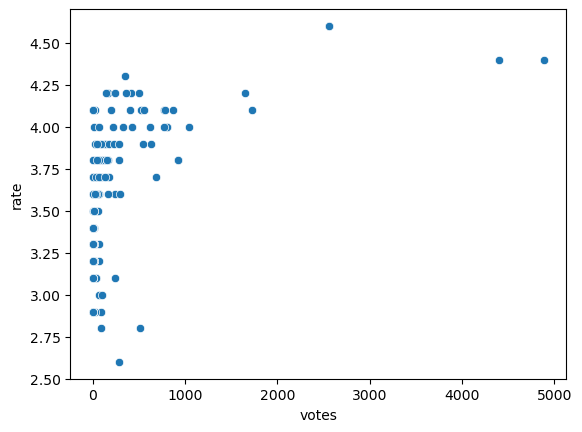

In [64]:
sns.scatterplot(
    data=df,
    x='votes',
    y='rate'
)
plt.show()

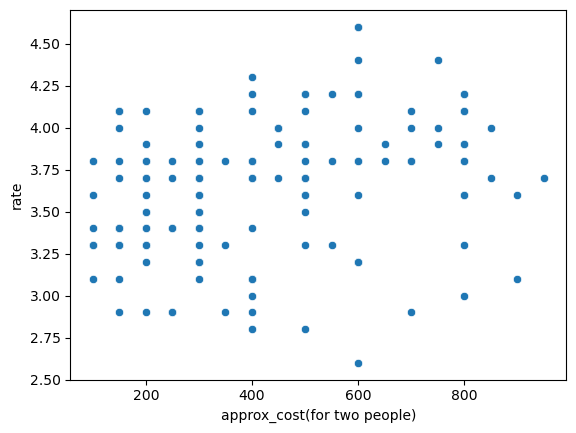

In [66]:
sns.scatterplot(
    data=df,
    x='approx_cost(for two people)',
    y='rate'
)
plt.show()

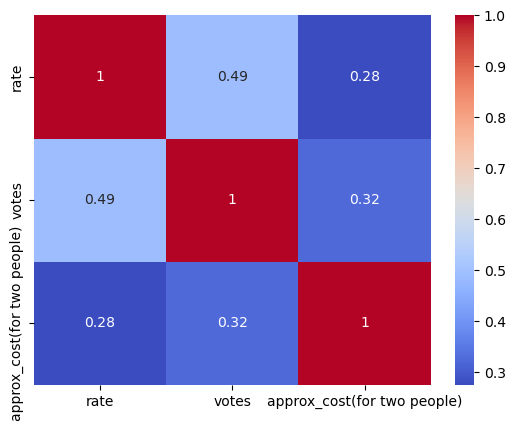

In [68]:
numeric_df = df[['rate',
                 'votes',
                 'approx_cost(for two people)']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [70]:
df['Cost_Per_Rating'] = (
    df['approx_cost(for two people)'] /
    df['rate']
)

In [72]:
df['Popularity_Score'] = (
    df['votes'] * df['rate']
)

In [74]:
df['Premium_Restaurant'] = (
    df['approx_cost(for two people)'] > 600
).astype(int)